# Part 1


Imports

In [7]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

Settings

In [8]:
SEED = 42
MODEL_NAME = "distilbert-base-uncased"
DATA_PATH = r"dataset/jigsaw-unintended-bias-train.csv"

# CPU-friendly settings for now
TRAIN_SIZE = 10_000
EVAL_SIZE = 2_000
MAX_LEN = 128
OUTPUT_DIR = "saved_models/part1_distilbert"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

os.makedirs("saved_models", exist_ok=True)
os.makedirs("plots", exist_ok=True)

Device: cpu


Load dataset

In [9]:
print("Loading dataset...")

df = pd.read_csv(
    DATA_PATH,
    usecols=[
        "comment_text",
        "toxic",
        "black",
        "white",
        "muslim",
        "jewish",
        "homosexual_gay_or_lesbian"
    ]
)

df = df.dropna(subset=["comment_text", "toxic"]).copy()
df["label"] = (df["toxic"] >= 0.5).astype(int)

print("Full dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nLabel distribution:")
print(df["label"].value_counts(normalize=True))

Loading dataset...
Full dataset shape: (1902191, 8)
Columns: ['comment_text', 'toxic', 'black', 'homosexual_gay_or_lesbian', 'jewish', 'muslim', 'white', 'label']

Label distribution:
label
0    0.920034
1    0.079966
Name: proportion, dtype: float64


Create stratified subsets

In [10]:
print("Creating stratified subsets...")

sample_total = TRAIN_SIZE + EVAL_SIZE

sampled_df, _ = train_test_split(
    df,
    train_size=sample_total,
    stratify=df["label"],
    random_state=SEED
)

train_df, eval_df = train_test_split(
    sampled_df,
    train_size=TRAIN_SIZE,
    test_size=EVAL_SIZE,
    stratify=sampled_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
eval_df = eval_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Eval shape :", eval_df.shape)

print("\nTrain label distribution:")
print(train_df["label"].value_counts(normalize=True))

print("\nEval label distribution:")
print(eval_df["label"].value_counts(normalize=True))

Creating stratified subsets...
Train shape: (10000, 8)
Eval shape : (2000, 8)

Train label distribution:
label
0    0.92
1    0.08
Name: proportion, dtype: float64

Eval label distribution:
label
0    0.92
1    0.08
Name: proportion, dtype: float64


Saving subsets 

In [11]:
train_df.to_csv("dataset/train_subset.csv", index=False)
eval_df.to_csv("dataset/eval_subset.csv", index=False)

print("Saved:")
print(" - dataset/train_subset.csv")
print(" - dataset/eval_subset.csv")

Saved:
 - dataset/train_subset.csv
 - dataset/eval_subset.csv


Load tokenizer

In [12]:
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["comment_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

Loading tokenizer...


Convert to HuggingFace dataset

In [13]:
print("Tokenizing datasets...")

train_hf = Dataset.from_pandas(
    train_df[["comment_text", "label"]],
    preserve_index=False
)

eval_hf = Dataset.from_pandas(
    eval_df[["comment_text", "label"]],
    preserve_index=False
)

train_hf = train_hf.map(tokenize_batch, batched=True)
eval_hf = eval_hf.map(tokenize_batch, batched=True)

train_hf = train_hf.remove_columns(["comment_text"])
eval_hf = eval_hf.remove_columns(["comment_text"])

train_hf.set_format("torch")
eval_hf.set_format("torch")

print(train_hf)
print(eval_hf)

Tokenizing datasets...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10000
})
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})


Metrics function

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = (probs >= 0.5).astype(int)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "auc_roc": roc_auc_score(labels, probs)
    }

Load model

In [15]:
print("Loading model...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training arguments

In [16]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    seed=SEED
)

print(training_args)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=epoch,
eval_use_gather_object=False,
fp16=False,
fp

Create trainer

In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=eval_hf,
    compute_metrics=compute_metrics
)

print("Trainer created successfully.")

Trainer created successfully.


Train

In [18]:
print("Starting training...")
trainer.train()

Starting training...


f:\areeba responsible\.venv\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Auc Roc
1,0.210756,0.186470,0.941500,0.773096,0.937928


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1250, training_loss=0.220451212310791, metrics={'train_runtime': 1822.4951, 'train_samples_per_second': 5.487, 'train_steps_per_second': 0.686, 'total_flos': 331168496640000.0, 'train_loss': 0.220451212310791, 'epoch': 1.0})

Predict on eval set

In [20]:
print("Running evaluation predictions...")

pred_output = trainer.predict(eval_hf)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_prob = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

print("Logits shape:", logits.shape)
print("Labels shape:", y_true.shape)

Running evaluation predictions...
Logits shape: (2000, 2)
Labels shape: (2000,)


Threshold sweep

In [21]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []

for th in thresholds:
    y_pred_temp = (y_prob >= th).astype(int)
    rows.append({
        "threshold": th,
        "accuracy": accuracy_score(y_true, y_pred_temp),
        "f1_macro": f1_score(y_true, y_pred_temp, average="macro"),
        "precision": precision_score(y_true, y_pred_temp, zero_division=0),
        "recall": recall_score(y_true, y_pred_temp, zero_division=0)
    })

threshold_df = pd.DataFrame(rows)
threshold_df

,threshold,accuracy,f1_macro,precision,recall
0,0.3,0.9425,0.788243,0.669173,0.55625
1,0.4,0.9420,0.778726,0.680328,0.51875
2,0.5,0.9415,0.773096,0.683761,0.50000
3,0.6,0.9410,0.768837,0.684211,0.48750
4,0.7,0.9430,0.767194,0.725490,0.46250


threshold

In [22]:
best_row = threshold_df.loc[threshold_df["f1_macro"].idxmax()]
BEST_THRESHOLD = float(best_row["threshold"])

print("Chosen threshold:", BEST_THRESHOLD)

y_pred = (y_prob >= BEST_THRESHOLD).astype(int)

Chosen threshold: 0.3


Final metrics

In [23]:
acc = accuracy_score(y_true, y_pred)
f1m = f1_score(y_true, y_pred, average="macro")
auc = roc_auc_score(y_true, y_prob)
cm = confusion_matrix(y_true, y_pred)

print("Accuracy :", acc)
print("F1 Macro :", f1m)
print("AUC-ROC  :", auc)
print("Confusion Matrix:\n", cm)

Accuracy : 0.9425
F1 Macro : 0.7882430711751865
AUC-ROC  : 0.9379279891304347
Confusion Matrix:
 [[1796   44]
 [  71   89]]


ROC curve

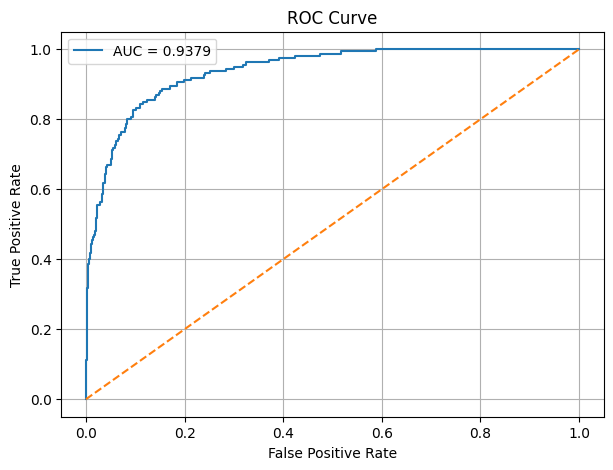

In [24]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

Precision-Recall curve

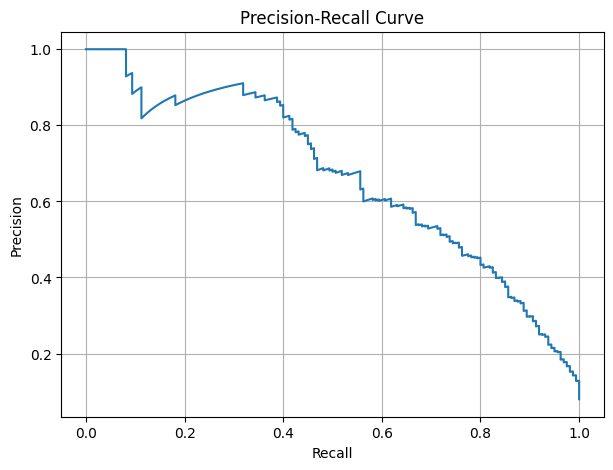

In [25]:
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

Confusion matrix plot

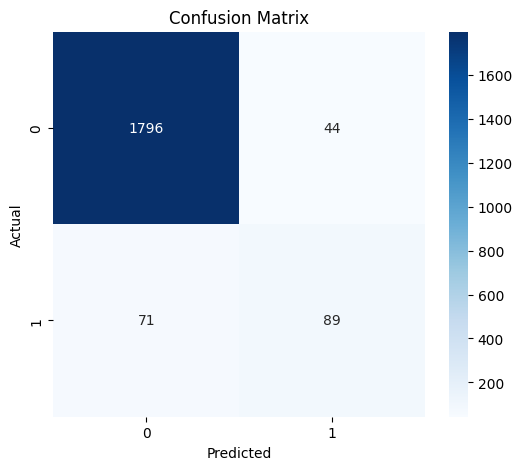

In [26]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

np.save("saved_models/part1_eval_probs.npy", y_prob)
np.save("saved_models/part1_eval_labels.npy", y_true)

with open("saved_models/part1_config.json", "w") as f:
    json.dump({
        "best_threshold": BEST_THRESHOLD,
        "model_dir": OUTPUT_DIR
    }, f, indent=2)

print("Saved files:")
print(" -", OUTPUT_DIR)
print(" - saved_models/part1_eval_probs.npy")
print(" - saved_models/part1_eval_labels.npy")
print(" - saved_models/part1_config.json")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved files:
 - saved_models/part1_distilbert
 - saved_models/part1_eval_probs.npy
 - saved_models/part1_eval_labels.npy
 - saved_models/part1_config.json
